<a href="https://colab.research.google.com/github/LuizDev544/AtividadesFabiano/blob/main/pokemonkaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tipagens de Pokemon #

Esse código tem o intuito de análisar as informações e atributos de Pokemons, com base de sua pokedex e definir ele utilizando o método de Machine Learning o SVM.

Aqui nós faremos o computador pensar e atribuir a sua tipagem com base de seus atributos como o "HP", "Attack", "Especial Attack" e enfim, para mostrar uma lógica de estudo que podemos fazer com base de seus dados atribuidos.
Como existem um total de 18 tipagens dividimos os seus valores em 3, assim criando grupos de 3 tipagens para uma melhor performance dentro do cálculo

# Importação de Bibliotecas #

In [26]:
# Importações das bibliotecas necessárias para a realização do código
import os
import kagglehub
path = kagglehub.dataset_download("darkmatternet/ultimate-pokmon-dataset-2025")

import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import seaborn as sb
import numpy as np

print(os.listdir(path))

Using Colab cache for faster access to the 'ultimate-pokmon-dataset-2025' dataset.
['pokemon_complete_2025.csv']


# Tratamento de Valores e Definições de Tabelas #

In [27]:
df = pd.read_csv(path + '/pokemon_complete_2025.csv')

# Removemos valores desnecessários dentro da tabela deixando apenas números importantes
Tratamento = df.drop(['genus', 'ability_1', 'ability_2', 'hidden_ability', 'growth_rate', 'is_baby','egg_groups', 'is_legendary', 'is_mythical', 'color', 'shape', 'habitat', 'generation', 'name', 'num_types', 'type_2', 'sprite_url', 'description', 'is_dual_type', 'gender_distribution', 'stat_tier'], axis=1)

mapeamento_tipos = { # Mapa dos tipos de pokemon de acordo com a sua numeragem
    'bug': 1, 'dark': 2, 'dragon': 3, 'electric': 4, 'fairy': 5, 'fighting': 6,
    'fire': 7, 'flying': 8, 'ghost': 9, 'grass': 10, 'ground': 11, 'ice': 12,
    'normal': 13, 'poison': 14, 'psychic': 15, 'rock': 16, 'steel': 17, 'water': 18
}

# Tratamos a tabela tipos para ela ter essa conversão de números e o SVM tratar eles
Tratamento['type_1'] = Tratamento['type_1'].map(mapeamento_tipos)

# Utilizamos a separação das tipagens em grupo
Grupo1 = Tratamento[Tratamento['type_1'].isin([1, 2, 3, 4, 5, 6])]      # bug, dark, dragon, electric, fairy, fighting
Grupo2 = Tratamento[Tratamento['type_1'].isin([7, 8, 9, 11, 12, 10])]   # fire, flying, ghost, ground, ice, grass
Grupo3 = Tratamento[Tratamento['type_1'].isin([13, 14, 15, 16, 17, 18])] # normal, poison, psychic, rock, steel, water

# Separar dados do grupo 1
Grupo1X = Grupo1.drop(['type_1'], axis=1)
Grupo1Y = Grupo1['type_1']

# Separar dados do grupo 2
Grupo2X = Grupo2.drop(['type_1'], axis=1)
Grupo2Y = Grupo2['type_1']

# Separar dados do grupo 3
Grupo3X = Grupo3.drop(['type_1'], axis=1)
Grupo3Y = Grupo3['type_1']

# Criação do Machine Learn e Previsão de Valores do Grupo 1 #

In [28]:
# PRIMEIRO GRUPO
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear','poly']
}

XGrupo1Treino, XGrupo1Teste, YGrupo1Treino, YGrupo1Teste = train_test_split(Grupo1X, Grupo1Y, test_size=0.20, random_state=42)

# Utilizamos o StandardScaler para transformar todos os dados em uma mesma escala
scaler1 = StandardScaler()

# Realizamos as escalas do grupo X de treino e teste
XEscalaGrupo1 = scaler1.fit_transform(XGrupo1Treino)
XTesteEscalaGrupo1 = scaler1.transform(XGrupo1Teste) # Corrigido o nome para clareza

# Instanciamos o SVM base mantendo o class_weight='balanced'
# Não passamos o 'kernel' fixo aqui, pois o Grid Search testará os do param_grid
svm_base = SVC(class_weight='balanced')

# Configuramos o Grid Search
# O refit=True garante que o melhor modelo será retreinado automaticamente com todo o treino
grid_search = GridSearchCV(estimator=svm_base, param_grid=param_grid, refit=True, verbose=2, cv=5)

# Executamos a busca exaustiva usando os dados de treino escalados
grid_search.fit(XEscalaGrupo1, YGrupo1Treino)

# Exibe na tela quais foram os melhores hiperparâmetros encontrados
print("Melhores parâmetros encontrados:", grid_search.best_params_)

# O próprio objeto grid_search usa o melhor modelo configurado para fazer a previsão
PrevisaoGrupo1 = grid_search.predict(XTesteEscalaGrupo1)

# Imprime o relatório de classificação do melhor modelo encontrado
print(classification_report(YGrupo1Teste, PrevisaoGrupo1, zero_division=0))

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1

# Criação do Machine Learn e Previsão de Valores do Grupo 2 #

In [21]:
# Segundo Grupo
param_grid_grupo2 = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear', 'poly']
}

XGrupo2Treino, XGrupo2Teste, YGrupo2Treino, YGrupo2Teste = train_test_split(Grupo2X, Grupo2Y, test_size=0.20, random_state=42)

# Utilizamos o StandardScaler específico para o grupo 2
scaler2 = StandardScaler()

# Realizamos as escalas corretas do X de treino e teste
XEscalaGrupo2 = scaler2.fit_transform(XGrupo2Treino)
XTesteEscalaGrupo2 = scaler2.transform(XGrupo2Teste)

# Instanciamos o SVM base para o grupo 2
svm_base2 = SVC(class_weight='balanced')

# Configuramos o Grid Search
grid_search2 = GridSearchCV(estimator=svm_base2, param_grid=param_grid_grupo2, refit=True, verbose=2, cv=5)

# Executamos a busca exaustiva usando os dados de treino escalados do Grupo 2
grid_search2.fit(XEscalaGrupo2, YGrupo2Treino)

# Exibe na tela quais foram os melhores hiperparâmetros encontrados
print("Melhores parâmetros encontrados (Grupo 2):", grid_search2.best_params_)

# O próprio objeto grid_search usa o melhor modelo configurado para fazer a previsão
PrevisaoGrupo2 = grid_search2.predict(XTesteEscalaGrupo2)

# Imprime o relatório de classificação do melhor modelo encontrado
print(classification_report(YGrupo2Teste, PrevisaoGrupo2, zero_division=0))

Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale

# Criação do Machine Learn e Previsão de Valores do Grupo 3 #

In [22]:
# TERCEIRO GRUPO
param_grid_grupo3 = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear', 'poly']
}

XGrupo3Treino, XGrupo3Teste, YGrupo3Treino, YGrupo3Teste = train_test_split(Grupo3X, Grupo3Y, test_size=0.20, random_state=42)

# Utilizamos o StandardScaler específico para o grupo 3
scaler3 = StandardScaler()

# Realizamos as escalas corretas do X de treino e teste
XEscalaGrupo3 = scaler3.fit_transform(XGrupo3Treino)
XTesteEscalaGrupo3 = scaler3.transform(XGrupo3Teste)

# Instanciamos o SVM base para o grupo 3
svm_base3 = SVC(class_weight='balanced')

# Configuramos o Grid Search
grid_search3 = GridSearchCV(estimator=svm_base3, param_grid=param_grid_grupo3, refit=True, verbose=2, cv=5)

# Executamos a busca exaustiva usando os dados de treino escalados do Grupo 3
grid_search3.fit(XEscalaGrupo3, YGrupo3Treino)

# Exibe na tela quais foram os melhores hiperparâmetros encontrados
print("Melhores parâmetros encontrados (Grupo 3):", grid_search3.best_params_)

# O próprio objeto grid_search usa o melhor modelo configurado para fazer a previsão
PrevisaoGrupo3 = grid_search3.predict(XTesteEscalaGrupo3)

# Imprime o relatório de classificação do melhor modelo encontrado
print(classification_report(YGrupo3Teste, PrevisaoGrupo3, zero_division=0))

Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale

# Criação da Matriz de Confusão do Grupo 1 #

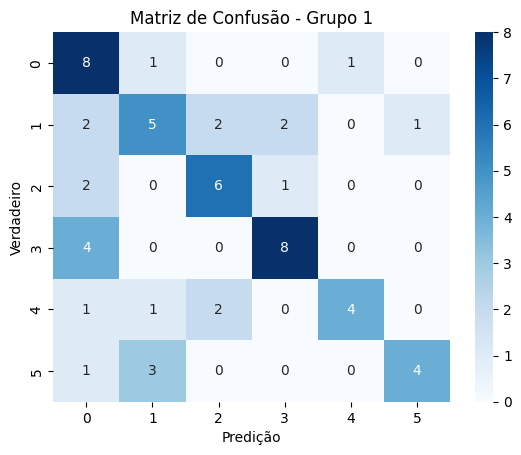

In [23]:
# Matriz de Confusão Grupo 1

cm = confusion_matrix(YGrupo1Teste, PrevisaoGrupo1)

sb.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predição")
plt.ylabel("Verdadeiro")
plt.title('Matriz de Confusão - Grupo 1')
plt.show()

# Criação da Matriz de Confusão do Grupo 2 #

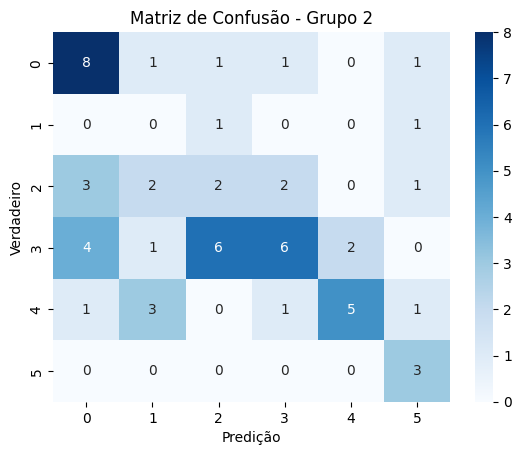

In [24]:
# Matriz de Confusão Grupo 2

cm = confusion_matrix(YGrupo2Teste, PrevisaoGrupo2)

sb.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predição")
plt.ylabel("Verdadeiro")
plt.title('Matriz de Confusão - Grupo 2')
plt.show()

# Criação da Matriz de Confusão do Grupo 3 #

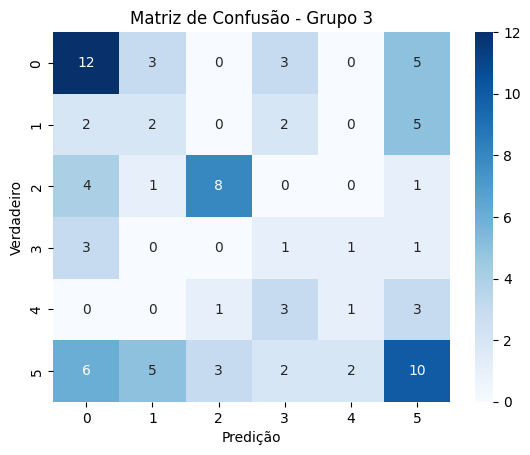

In [25]:
# Matriz de Confusão Grupo 3

cm = confusion_matrix(YGrupo3Teste, PrevisaoGrupo3)

sb.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predição")
plt.ylabel("Verdadeiro")
plt.title('Matriz de Confusão - Grupo 3')
plt.show()